# Lesson 109 · Database timestamps: reconstruct what was known

Student lab · Three live TODOs, immediate CHECKs, and a written EXIT. Default CPU execution reconstructs the entire selected F1 label/heuristic experiment. The separate source and SQL graph audits have exact repository commands in the protocol. No learner mastery is inferred.

In [ ]:
# @colab-bootstrap — CPU-only; downloads less than 1 MB of public input archives.
import sys,subprocess,importlib.metadata
required={'numpy':'2.5.0','pandas':'3.0.3','pyarrow':'24.0.0'}
missing=[]
for package,version in required.items():
    try:current=importlib.metadata.version(package)
    except importlib.metadata.PackageNotFoundError:current=None
    if current!=version:missing.append(package+'=='+version)
if missing:subprocess.check_call([sys.executable,'-m','pip','install',*missing])
print('Python',sys.version.split()[0], 'runtime pins',required)


<p class="stream-label">One skill: turn database history into a defensible prediction-time graph</p>

You have learned to sample a temporal graph. Now someone hands you a database containing `created_at`, `updated_at`, and `date`. Which one should govern the graph? **By the end, you will write a timestamp contract, reconstruct historical row versions, and prove that a join uses the information available at its query time.**

This is the hand-off from [L096’s SQL-to-graph mapping](https://avistian.github.io/relational/lessons/0096-multi-relational-data.html), [L104’s leakage audit](https://avistian.github.io/relational/lessons/0104-information-leakage-in-time.html), and [L108’s temporal sampler](https://avistian.github.io/relational/lessons/0108-temporal-neighbor-sampling.html) to relational learning. A powerful sampler cannot recover a historical value that the database has overwritten. The mission requires both meaningful relational structure and an honest account of when it became usable.



## First retrieve, without notes



1. An event happened on day 2 and arrived on day 7. Can a day-5 prediction use it?
2. Why can a correct foreign-key join still leak future information?
3. What separates a target’s prediction time from the time it becomes safe to train on it?

<details><summary>Check after writing</summary>

No: it was not available by day 5. A key can link to a future row or a corrected value that was unknown at the query time. A future-window target must wait until the window has ended and the necessary outcomes are available, under a declared completeness policy.

</details>



## 1 · Name the clocks before choosing a column

> **In plain terms.** “When did this happen?” and “When could our predictor know it?” are separate questions.

An **event time** marks an occurrence: a purchase, a race result, or a payment. An **availability time**, called `observed_at` here, marks when that information becomes usable by the prediction system. A queue delay, batch import, or feature-processing delay can separate them.

A **valid time** describes when a state applies in the world. For example, an address may be effective from day 2 even though its correction arrives on day 8. Valid time is useful for state histories; event time is useful for immutable occurrences. Do not give one column both meanings without a reason.

A **system time** records when a particular storage system recorded a version. It can supply availability evidence, but only if that system is the boundary your predictor actually reads. A downstream system may learn the value later. [Fowler’s bitemporal history](https://martinfowler.com/articles/bitemporal-history.html) explains the two historical questions; [SQL Server’s temporal-table documentation](https://learn.microsoft.com/en-us/sql/relational-databases/tables/temporal/overview?view=sql-server-ver17) describes system-managed row histories. Neither a suggestive column name nor an old effective date establishes model availability.

| Column | Question to resolve before use |
|---|---|
| `created_at` | Creation of the entity, source row, or warehouse copy? Does this timestamp cover every field? |
| `updated_at` | Does it describe the current version only? Where are the old values? |
| `date` | Event occurrence, calendar date, planned date, or publication date? |
| `observed_at` | Observed by which system? Is the value already usable by the predictor then? |

**Worked example.** An immutable event has event time 2 and observed time 7. The query cutoff is 5. Checking only `2 <= 5` admits it. Checking both clocks rejects it because `7 <= 5` is false.

<figure class="stream-figure" tabindex="0">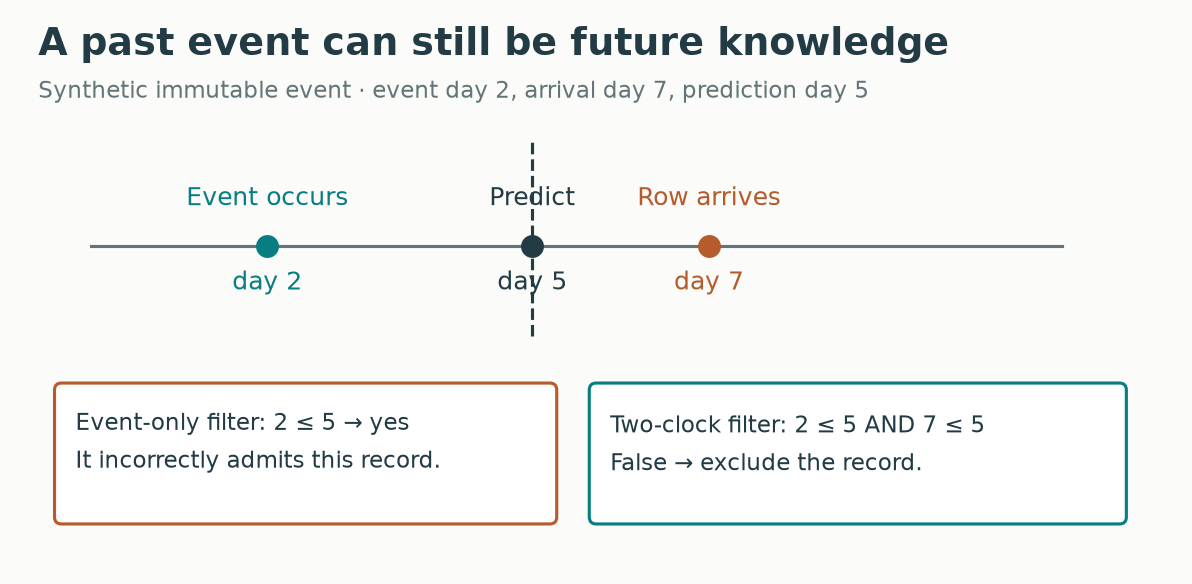<figcaption>Synthetic immutable event: occurred day 2, observed day 7; exclude from the day-5 query.</figcaption></figure>

Implement `legal_history` in the live TODO below.

**Boundary contract.** This lesson uses inclusive visibility: a fully available record at cutoff `t` may be used at `t`. L108’s TGAT event prediction uses strict-past history, excluding events at its cutoff. These represent different prediction orders. If a timestamp tie does not establish whether the query happened before or after publication, use a conservative boundary or an explicit sequence number. Do not let file order decide.

**Clock units.** Real-data comparisons use pandas timestamps with the release’s timezone-naive semantics. The synthetic lab uses integer days in one common clock. A production contract should declare timezone, precision, clock source and tie ordering. Converting a date without a time into midnight does not prove that all its fields were known at midnight.



## 2 · Reconstruct the value before joining it

> **In plain terms.** A historical query needs the old answer and the old relationship.

An **append-only history** retains each received version instead of replacing the previous one. A **revision** identifies a correction. A **tombstone** is a stored deletion marker; it must win version selection before the deleted row disappears.

Our bounded state representation stores `id`, `valid_from`, `observed_at`, `revision`, `deleted`, and the row’s values. A new `valid_from` starts an effective step. Revisions with the same `valid_from` correct that step. At cutoff `t`, first keep versions with both `valid_from <= t` and `observed_at <= t`. Within each ID, choose the greatest `(valid_from, observed_at, revision)` tuple. Finally remove selected tombstones. Duplicate version keys are rejected, because they would make the answer ambiguous.

**Worked example.** Fact `r` became effective on day 2. Its first version arrived on day 3 and pointed to person A. A correction arrived on day 8 and pointed to B. A deletion arrived on day 10. A itself has value 1 until a retroactive correction arrives on day 9; B first becomes available on day 7.

<figure class="stream-figure" tabindex="0">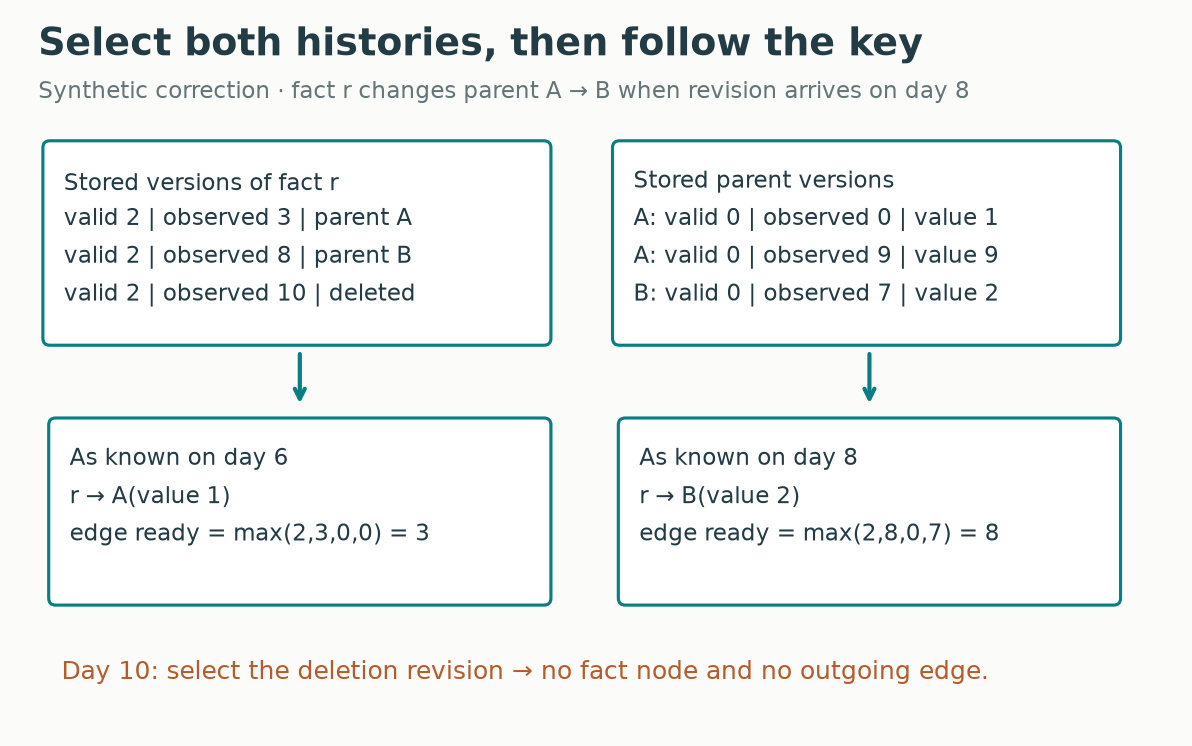<figcaption>Synthetic append-only histories: select both row versions before joining their keys. Day 10 removes the selected tombstone.</figcaption></figure>

At query 6, choose `r → A` and A’s value 1. At query 8, choose `r → B` and B’s value 2. At query 10, select the deletion and remove `r`. Dropping deletion records *before* version selection would incorrectly resurrect `r`.

Implement `asof_versions` in the live TODO below.

An **as-of join** joins the versions appropriate to a historical cutoff. Here we first reconstruct both tables, then follow the selected fact’s foreign key. Joining current rows and filtering only the fact’s original creation time would retain the corrected relationship at earlier cutoffs.

**Predict first:** move the cutoff from 6 to 8. Which parent becomes visible? Then move it to 10. Does the deleted fact regain its older parent?

**Portable prediction task:** write the selected edge, parent value and readiness at days 6, 8 and 10. Use the worked answer only after committing.

<details><summary>Worked answer, including a no-JavaScript fallback</summary>

The default day-6 state is `r → A`, A value 1, edge ready day 3. Day 8 uses the revised key `r → B`, B value 2, edge ready day 8. Day 10 contains no fact or edge. A’s correction at day 9 changes A’s value, but does not redirect `r` back to A. All stored versions stay fixed while the control changes the query cutoff.

</details>

> **Scope check.** This is an explicit effective-step representation with corrections, not a general engine for overlapping valid-time intervals. A historical question can also use separate effective and knowledge cutoffs; our prediction query sets both to the same `t`. Future schedules known in advance need their own feature contract rather than being treated as already-completed events.



## 3 · Emit a graph with an auditable timestamp contract

A **primary key** identifies a row within a table. A **foreign key** names a row in another table. A **relational entity graph (REG)** represents each row as a typed node and each selected key link as a typed edge. “Typed” means that a driver node and a result node retain their different table identities.

Our graph path is: **stored versions → historical rows → historical key join → typed nodes and edges**. The values and relationships come from the same historical state. A two-hop message cannot bypass that state by fetching a neighbor from a current-table cache.

In the synthetic implementation, an edge’s readiness is the maximum of the selected child’s valid and observed times and the selected parent’s valid and observed times. For day-6 `r → A`, this is `max(2,3,0,0) = 3`. For day-8 `r → B`, it is `max(2,8,0,7) = 8`. Readiness alone is insufficient: the edge also needs the selected versions, so an obsolete edge does not stay active forever.

**Missing endpoint.** A **dangling reference** points to a parent absent from the selected snapshot. We retain the child node, omit that edge, and count the omission. We do not invent a parent or silently reconnect to its newest version. Null foreign keys create no edge.

**Multi-hop meaning.** This graph represents the database as known at one root cutoff. Every hop uses that snapshot. TGAT’s recursive child cutoff in L108 answers a different question: represent a neighbor at the connecting event’s time. Do not accidentally mix these two graph semantics.

| Contract field | Synthetic versioned graph | Pinned F1 release graph |
|---|---|---|
| Node identity | `(table, row ID)` | `(table, stable reindexed primary key)` |
| Time predicate | effective and observed by query | table’s `time_col <= query` |
| State changes | append-only revisions and tombstones | historical revisions unavailable |
| Relationship | FK in selected child version | FK in released row |
| Undated table | explicit historical versions | assumed eligible at every cutoff |
| Missing endpoint | omit edge; count it | omit edge; count it |

The full implementation is visible in the lab. The real-data graph function returns node-ID arrays and one `[number_of_edges, 2]` integer array per relation. These IDs remain stable after filtering; they are not automatically dense tensor row offsets. A later model must construct an explicit ID-to-tensor-index mapping. No neural encoder or GNN training is introduced here.



## 4 · Keep feature time separate from label time

> **In plain terms.** A future outcome is the answer you train toward. It must not become part of the earlier question.

A **prediction horizon** specifies how far ahead the target looks. For query time `t` and horizon `h`, our target window is `(t, t+h]`: exclude the query instant, include the end. Features must satisfy the query’s information contract. Outcomes in the future window belong only on the label side.

**Worked example.** Query at 5, horizon 4, last required outcome arrives at 12. The outcome window ends at 9, but its label cannot be used for fitting at 9 if a constituent is missing until 12. Under a completeness certificate, its earliest fit time is `max(9,12) = 12`.

<figure class="stream-figure" tabindex="0">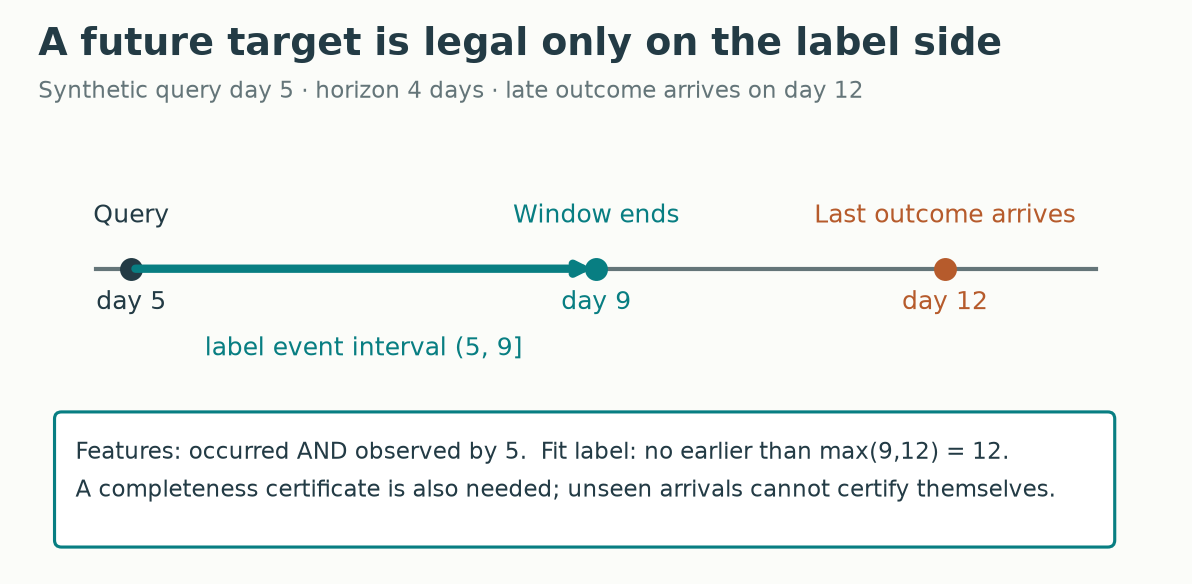<figcaption>Synthetic label window (5,9], with final constituent arrival on 12; fit no earlier than 12 under certified completeness.</figcaption></figure>

Implement `label_ready` in the live TODO below.

A **watermark** or completeness certificate states that all required events through a boundary have arrived under a defined policy. Taking the maximum arrival time of records already in memory does not prove that another record is not still missing. Even a zero-count label needs a closed window. Later corrections also require a label-version policy. The lab’s maturity function assumes certified completeness; it does not manufacture that certificate.

For a validation fit at time `b`, require each fitting label’s readiness to be at most `b`. Fit preprocessing and encoders using the permitted fitting data too. Correct graph filtering cannot repair an encoder that has already learned from future rows.



## 5 · Reproduce the complete selected F1 experiment

The primary reading is [Robinson et al., RelBench v1, §2 and §5.2/Table 4](https://arxiv.org/html/2407.20060v1). Read the split and regression definitions, then inspect the pinned [task SQL](https://github.com/snap-stanford/relbench/blob/9aa346267c2e1c560bd92da07d6f4ad1ca2f0639/relbench/tasks/f1.py) and [dataset timestamp construction](https://github.com/snap-stanford/relbench/blob/9aa346267c2e1c560bd92da07d6f4ad1ca2f0639/relbench/datasets/f1.py). This package targets the entire five-heuristic slice for **rel-f1/driver-position**, on both validation and test.

**What changes from L101?** L101 read cached task labels. Here we start from all nine released database tables, rebuild the query schedules, regenerate every target, compare every query identity and target with the archive and original SQL, and only then compute predictions.

**Follow one target.** At a query date, select result rows in the next 60 days. Group them by driver. Average `positionOrder`, the finishing-order field. The column named `position` in the task table is this average; it is not a direct copy of the database’s separate `position` field. A driver with no result in that future window has no task row. This matters for interpreting the prediction population.

**Released schedule.** Training starts 60 days before 2005-01-01 and steps backward to the database’s earliest timed row. Validation steps forward from 2005-01-01 until the final complete window before 2010-01-01. Test starts at 2010-01-01 and uses at most 40 windows. Empty windows do not create examples. We generate the schedule independently and also execute the original scheduling and SQL code.

**Released quirks.** The task’s one-year “activity” subquery has a lower date bound but no upper bound. A selected future result already satisfies that predicate. We preserve it for exact comparison, then count how many task queries lack a genuinely prior-year result. This is a query-population audit, not a new paper benchmark. An alternative deployment task would define eligible drivers from known history, specify a target for no future race, and require separate evaluation.

**Timestamp assumptions.** The dataset assigns race timestamps to result and standings rows; qualifying is assigned the race timestamp minus one day. Drivers, constructors and circuits have no time column. These are release conventions, not measured ingestion times. A race start time does not certify that its final results were available then. Scheduled-race attributes and outcome fields may need different availability contracts in a deployment.

**Estimators.** Zero predicts 0. Global mean and median use all permitted fitting targets. Entity mean and median use that driver’s fitting targets, falling back to 0 for an unseen driver. Validation uses training labels; test uses training plus validation labels. These are deterministic estimators: no neural architecture, optimizer, random seeds or hyperparameter search is involved.

**Metric.** Mean absolute error (MAE) averages `abs(prediction − target)` over all query rows. Its unit is finishing positions; lower is better. A frequently appearing driver contributes more rows. We declare an absolute tolerance of 0.0005 against each paper value printed to three decimals. Repeating a deterministic calculation with different seeds would not provide uncertainty estimates.

**Predict before results:** does matching all published scores prove that the historical feature values were available? Explain before reading.

**Author-reference evidence, not your current notebook output.** All 8,712 regenerated labels match both the cached targets and the original source SQL exactly.

| Split | Queries | Scheduled / nonempty windows | No prior-year result |
|---|---:|---:|---:|
| train | 7,453 | 332 / 254 | 955 |
| val | 499 | 30 / 23 | 33 |
| test | 760 | 40 / 33 | 42 |

| Estimator | Validation MAE | Test MAE | Paper rounding verdict |
|---|---:|---:|---|
| global zero | 11.083200 | 11.926206 | MATCH / MATCH |
| global mean | 4.334385 | 4.512881 | MATCH / MATCH |
| global median | 4.135571 | 4.399101 | MATCH / MATCH |
| entity mean | 7.181002 | 8.501358 | MATCH / MATCH |
| entity median | 7.114262 | 8.518509 | MATCH / MATCH |

All ten fresh prediction vectors match the original baseline function within 1e-12. The real graph census checks **4,030 relations across 310 cutoffs**; all ordered edge arrays match independent SQL joins. The synthetic suite adds 520 SQL selector comparisons, 390 SQL graph comparisons and five rejected broken implementations. These are correctness counts, not accuracy confidence intervals. Paid compute: USD0.

<figure class="stream-figure" tabindex="0">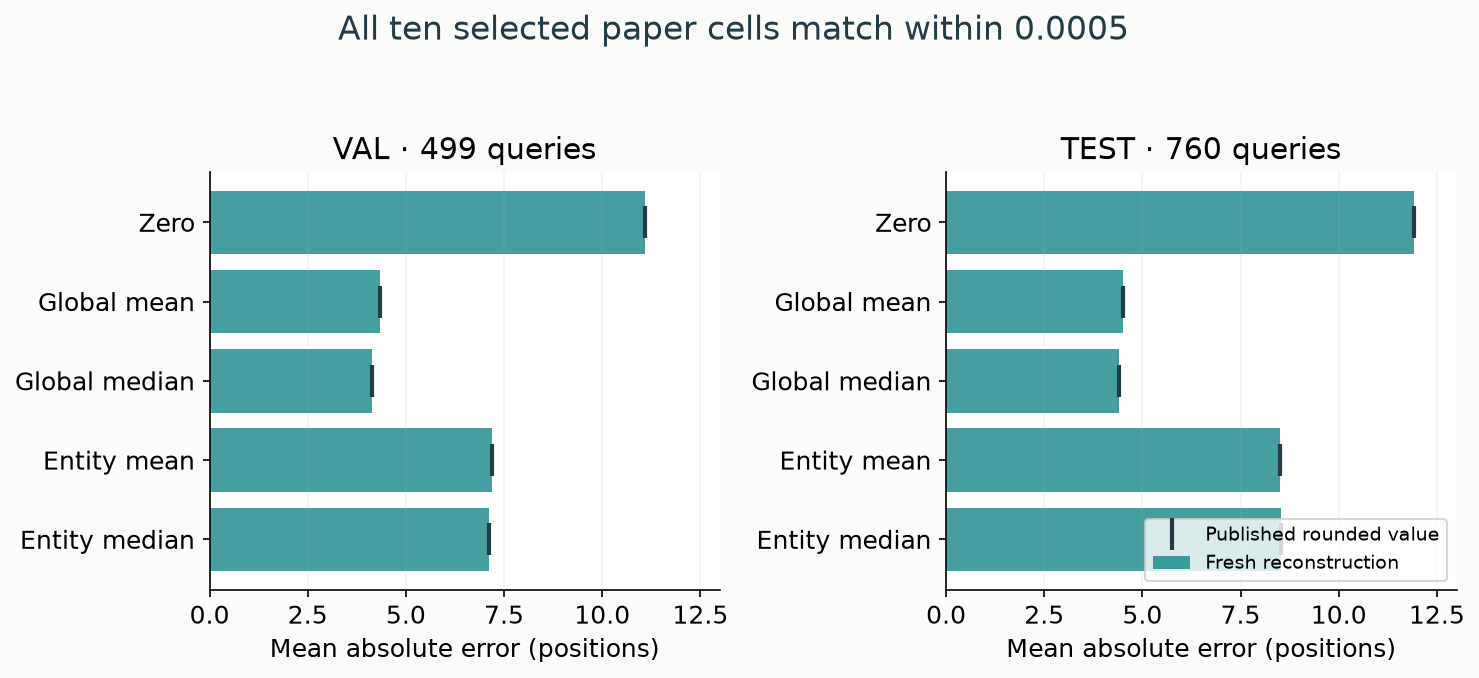<figcaption>Author-reference reconstruction: full selected validation/test populations, all five deterministic methods. Ticks show rounded paper targets; no seed uncertainty applies.</figcaption></figure>

**Interpret the evidence.** The independent pandas implementation, unchanged released SQL, and cached targets agree. The original baseline function also agrees with all ten fresh prediction vectors. The graph census independently checks every relation at every distinct released query cutoff using SQL joins. These checks support the named reconstruction and stated timestamp policy; they do not establish real historical availability.

> **Scope check.** Complete selected reproduction is achieved for the database-to-label reconstruction and five-heuristic slice. Raw Kaggle-to-database processing, LightGBM/RDL columns, other tasks and the rest of the paper are not reproduced. Historical execution identity and full-paper parity remain **NOT_ESTABLISHED**. Real ingestion/version histories are **NOT_AVAILABLE**. Synthetic history tests are separate course evidence. Live Colab and deployment remain **NOT_CHECKED** unless separately verified.



## 6 · Build and defend your own contract

Open the [student lab](https://avistian.github.io/relational/labs/0109-database-timestamp-contracts.ipynb), [executed solution](https://avistian.github.io/relational/labs/html/0109-database-timestamp-contracts.html), and [reproduction contract](https://avistian.github.io/relational/labs/l109-reproduction.md). The notebook includes the visible implementation, downloads hash-pinned inputs, and executes the complete selected numerical reconstruction on CPU. It has three live tasks: historical version selection, two-clock event eligibility, and label readiness. Their outputs are used by the graph and boundary checks; they are not decorative exercises.

**Predict → implement → measure → diagnose.** Predict the effect of a late correction. Implement the selectors. Run the full reconstruction. Diagnose why reproducing the released score still leaves ingestion-time assumptions unproven.

For your EXIT, submit a timestamped two-table graph specification with a late record, a corrected key, and a deletion. State each clock’s origin, boundary convention, row-version rule, dangling-key policy, and label completeness assumption. Supply one failing counterexample to event-only filtering and one to joining current rows. Include your fresh label/baseline report and explain the future-conditional driver population.

**Written defense:** distinguish the two historical clocks, version selection, graph visibility, label maturity and what the reproduction proves.

Ask the teaching agent follow-up questions or paste your contract for review. Author execution does not establish learner mastery: **PENDING_WRITTEN_DEFENSE**. For spaced practice, reconstruct the day-6 join tomorrow without notes, then add a delayed parent three days later. L110’s checkpoint will require these boundaries to survive a complete temporal model pipeline; Year 4 will carry them into database graph construction.

[Timestamp contract reference](https://avistian.github.io/relational/reference/database-timestamp-contracts.html) · [L101](https://avistian.github.io/relational/lessons/0101-static-vs-temporal.html) · [L108](https://avistian.github.io/relational/lessons/0108-temporal-neighbor-sampling.html)


## Implement the historical contract

The following synthetic fixtures have the two clocks and version histories absent from the F1 archive. Their tests exercise your code directly.

In [ ]:
# PROVIDED — stored histories are held fixed throughout the temporal intervention.
people=[dict(id='A',valid_from=0,observed_at=0,revision=0,deleted=False,value=1),
        dict(id='A',valid_from=0,observed_at=9,revision=1,deleted=False,value=9),
        dict(id='B',valid_from=0,observed_at=7,revision=0,deleted=False,value=2)]
facts=[dict(id='r',valid_from=2,observed_at=3,revision=0,deleted=False,person='A',value=5),
       dict(id='r',valid_from=2,observed_at=8,revision=1,deleted=False,person='B',value=6),
       dict(id='r',valid_from=2,observed_at=10,revision=2,deleted=True,person='B',value=6)]


### PROVIDED · validate the history before selecting values

In [ ]:
import math

def validate_versions(rows):
    """Numeric UTC offsets in one declared unit; unique (id, valid, observed, revision)."""
    keys=set()
    for row in rows:
        for column in ('valid_from','observed_at'):
            value=row.get(column)
            if not isinstance(value,(int,float)) or not math.isfinite(value):
                raise ValueError('Missing/nonfinite '+column)
        if not isinstance(row.get('revision'),int) or row['revision']<0:
            raise ValueError('Revision must be a nonnegative tie-break integer')
        if not isinstance(row.get('deleted'),bool):
            raise ValueError('Explicit tombstone flag required')
        key=(row['id'],row['valid_from'],row['observed_at'],row['revision'])
        if key in keys:
            raise ValueError('Ambiguous version key')
        keys.add(key)

### TODO · select the state known at the query time

**Goal:** select one eligible historical version per ID. **Why:** a later value or key must not enter an earlier graph. **Hint:** eligibility, ordered selection, and deletion are three distinct steps; filter tombstones last.

In [ ]:
def asof_versions(rows, cutoff):
    raise NotImplementedError("TODO: asof_versions")

### CHECK · asof_versions

In [ ]:
assert asof_versions(people,6)['A']['value']==1, 'A late correction cannot rewrite a day-6 feature'
assert 'B' not in asof_versions(people,6), 'B is not observed until day 7'
assert asof_versions(facts,8)['r']['person']=='B', 'Cutoff ties are inclusive here'
assert not asof_versions(facts,10), 'Select the tombstone before removing the deleted row'
print('PASS: corrections, availability, ties and deletion')

### TODO · filter immutable events using both clocks

**Goal:** return eligible immutable-event indices. **Why:** event time alone admits late arrivals. **Hint:** the query must satisfy both clock comparisons under the stated boundary.

In [ ]:
def legal_history(rows, cutoff):
    raise NotImplementedError("TODO: legal_history")

### CHECK · legal_history

In [ ]:
events=[{'event_time':2,'observed_at':7},{'event_time':5,'observed_at':5},{'event_time':9,'observed_at':3}]
assert legal_history(events,5)==[1], 'Both clocks must satisfy this inclusive cutoff'
assert legal_history(events,7)==[0,1]
print('PASS: both clocks and inclusive boundary')

### PROVIDED · join historical versions before emitting graph edges

In [ ]:
def graph_at(people, facts, cutoff):
    """A fixed-cutoff snapshot graph; foreign keys live in versioned fact rows.

    A row is a typed node. An edge exists only if both historical endpoints exist.
    Missing parents remain dangling references for audit; no guessed parent is added.
    """
    left=asof_versions(facts,cutoff);right=asof_versions(people,cutoff)
    edges=[];dangling=[]
    for fact_id,fact in sorted(left.items()):
        parent=right.get(fact['person'])
        if parent is None:
            dangling.append(fact_id)
            continue
        ready=max(fact['valid_from'],fact['observed_at'],parent['valid_from'],parent['observed_at'])
        edges.append((fact_id,parent['id'],ready))
    return {'nodes':{'facts':left,'people':right},'edges':edges,'dangling':dangling,'cutoff':cutoff}

### TODO · wait for a mature label

**Goal:** calculate the earliest fit time under certified completeness. **Why:** an ended window can still be missing outcomes. **Hint:** neither the horizon nor the constituent arrivals may be ignored.

In [ ]:
def label_ready(query_time, horizon, arrivals):
    raise NotImplementedError("TODO: label_ready")

### CHECK · label_ready

In [ ]:
assert label_ready(5,4,[6,12])==12, 'A late constituent delays fitting'
assert label_ready(5,4,[])==9, 'Zero outcomes still require a closed future window'
assert label_ready(5,4,[6,7])==9, 'Early arrivals do not shorten the target horizon'
print('PASS: window closure and constituent arrival; completeness is assumed')

## Trace the historical graph and label boundary

In [ ]:
# CHECK/RUN — the graph calls YOUR historical selector, with no fallback implementation.
for day,expected in [(6,[('r','A',3)]),(8,[('r','B',8)]),(10,[])]:
    graph=graph_at(people,facts,day)
    assert graph['edges']==expected
    print('day',day,':',graph['edges'])
# Three questions share the same stored immutable events; YOUR eligibility function executes.
events=[{'event_time':2,'observed_at':7},{'event_time':5,'observed_at':5}]
for day in [5,6,7]:print('legal event indices at',day,legal_history(events,day))
assert label_ready(5,4,[6,12])>9
print('Do not fit the day-5 label at day 9: the source is incomplete.')


## Complete selected reproduction implementation

These PROVIDED functions expose the full archive verification, source-derived query schedule, independent target construction and five deterministic estimators. Read `regenerate` alongside `DriverPositionTask.make_table` in the pinned source. No neural model or training loop applies to these heuristic estimators. Targets are regenerated before fitting; predictions cannot inspect evaluation targets.

### PROVIDED · authenticate two public archives before parsing

In [ ]:
import hashlib
import io
import json
import urllib.request
import zipfile
from pathlib import Path
import numpy as np
import pandas as pd
import pyarrow.parquet as pq

SOURCE_COMMIT='9aa346267c2e1c560bd92da07d6f4ad1ca2f0639'
ARCHIVES={
 'db.zip':('https://relbench.stanford.edu/download/rel-f1/db.zip','ec31a4e1bc2b2f9c36c05fcd3dfe2a40a506f335dc51ce79c3ec8bb40feb1482'),
 'driver-position.zip':('https://relbench.stanford.edu/download/rel-f1/tasks/driver-position.zip','775b28a51604169539bbe712a2f0d15158c112bc6abf316cdd0995087a7ae03e')}
ARMS=['global_zero','global_mean','global_median','entity_mean','entity_median']
TARGETS={'val':[11.083,4.334,4.136,7.181,7.114],'test':[11.926,4.513,4.399,8.501,8.519]}
VAL=pd.Timestamp('2005-01-01');TEST=pd.Timestamp('2010-01-01');HORIZON=pd.Timedelta(days=60)

def load_inputs(cache):
    cache=Path(cache);cache.mkdir(parents=True,exist_ok=True)
    frames={};metadata={}
    for name,(url,digest) in ARCHIVES.items():
        path=cache/name
        raw=path.read_bytes() if path.exists() else urllib.request.urlopen(url,timeout=60).read()
        if hashlib.sha256(raw).hexdigest()!=digest:
            raise ValueError('Archive identity mismatch: '+name)
        if not path.exists():path.write_bytes(raw)
        frames[name]={}
        with zipfile.ZipFile(io.BytesIO(raw)) as archive:
            for member in archive.namelist():
                if not member.endswith('.parquet'):continue
                table=pq.read_table(io.BytesIO(archive.read(member)));key=Path(member).stem
                frames[name][key]=table.to_pandas()
                if name=='db.zip':
                    metadata[key]={k:json.loads(table.schema.metadata[k.encode()]) for k in ['pkey_col','time_col','fkey_col_to_pkey_table']}
    return frames['db.zip'],frames['driver-position.zip'],metadata

### PROVIDED · reconstruct the source's query schedule, including empty windows

In [ ]:
def schedule(tables,metadata,split):
    timed=[df[metadata[name]['time_col']] for name,df in tables.items() if metadata[name]['time_col'] is not None]
    if split in ['train','val']:timed=[x[x<=TEST] for x in timed]
    minimum=min(x.min() for x in timed);maximum=max(x.max() for x in timed)
    if split=='train':return pd.date_range(VAL-HORIZON,minimum,freq=-HORIZON)
    if split=='val':return pd.date_range(VAL,min(VAL+39*HORIZON,TEST-HORIZON),freq=HORIZON)
    if split=='test':return pd.date_range(TEST,min(TEST+39*HORIZON,maximum-HORIZON),freq=HORIZON)
    raise ValueError(split)

### PROVIDED · independent pandas reconstruction of DriverPositionTask.make_table

In [ ]:
def regenerate(tables,metadata,split):
    """Preserve the released future-conditional population; no silent protocol repair.

    The source's lower-only one-year activity predicate is redundant for a driver
    with a result in (t,t+60d]. The selected future result itself satisfies it.
    We keep the explicit predicate to expose the source behavior.
    """
    results=tables['results']
    if split!='test':results=results[results.date<=TEST]
    valid_drivers=set(tables['drivers'].driverId);parts=[]
    for t in schedule(tables,metadata,split):
        future=results[(results.date>t)&(results.date<=t+HORIZON)]
        active=set(results.loc[results.date>t-pd.DateOffset(years=1),'driverId'])
        future=future[future.driverId.isin(valid_drivers & active)]
        agg=future.groupby('driverId',as_index=False).positionOrder.mean().rename(columns={'positionOrder':'position'})
        agg.insert(0,'date',t);parts.append(agg)
    return pd.concat(parts,ignore_index=True)

### PROVIDED · deterministic estimators, no optimizer, search or seeds

In [ ]:
def baseline_predict(fit,query,arm):
    if arm=='global_zero':return np.zeros(len(query))
    if arm=='global_mean':return np.full(len(query),fit.position.mean())
    if arm=='global_median':return np.full(len(query),fit.position.median())
    if arm in ['entity_mean','entity_median']:
        estimates=fit.groupby('driverId').position.agg(arm.split('_')[1])
        return query.driverId.map(estimates).fillna(0).to_numpy(dtype=float)
    raise ValueError(arm)

### PROVIDED · full row-level comparisons and reproducible quantitative evidence

In [ ]:
def run_reproduction(cache,output):
    tables,tasks,metadata=load_inputs(cache);out=Path(output);out.mkdir(parents=True,exist_ok=True)
    regenerated={};audits={}
    for split,released in tasks.items():
        gen=regenerate(tables,metadata,split)
        assert not gen.duplicated(['date','driverId']).any()
        assert not released.duplicated(['date','driverId']).any()
        aligned=released[['date','driverId']].merge(gen,on=['date','driverId'],how='left',validate='one_to_one')
        assert len(gen)==len(released) and aligned.position.notna().all(),'Query populations differ'
        error=float(np.max(np.abs(aligned.position.to_numpy()-released.position.to_numpy())))
        assert error<=1e-12,'Regenerated labels differ'
        regenerated[split]=aligned
        # Future-conditional source population vs bounded prior activity: diagnostic only.
        inactive=0
        for t,group in released.groupby('date'):
            prior=tables['results'];prior=prior[(prior.date>t-pd.DateOffset(years=1))&(prior.date<=t)]
            inactive+=int((~group.driverId.isin(prior.driverId)).sum())
        audits[split]={'rows':len(gen),'scheduled_windows':len(schedule(tables,metadata,split)),'nonempty_windows':int(released.date.nunique()),'max_cached_label_error':error,'queries_without_prior_year_result':inactive}
        aligned.to_csv(out/(split+'-regenerated.csv'),index=False)
    assert (regenerated['train'].date+HORIZON<=VAL).all()
    assert (regenerated['val'].date+HORIZON<=TEST).all()
    predictions={};records=[]
    for split in ['val','test']:
        fit=regenerated['train'] if split=='val' else pd.concat([regenerated['train'],regenerated['val']],ignore_index=True)
        query=regenerated[split][['date','driverId']];truth=regenerated[split].position.to_numpy()
        for arm,target in zip(ARMS,TARGETS[split]):
            pred=baseline_predict(fit,query,arm);mae=float(np.abs(pred-truth).mean())
            records.append({'split':split,'arm':arm,'fit_rows':len(fit),'evaluation_rows':len(query),'mae':mae,'paper_mae':target,'gap':abs(mae-target),'verdict':'MATCH' if abs(mae-target)<=.0005 else 'FAIL'})
            predictions[split+'_'+arm]=pred
        predictions[split+'_target']=truth
        predictions[split+'_driverId']=query.driverId.to_numpy()
        predictions[split+'_date_ns']=query.date.to_numpy(dtype='datetime64[ns]').astype('int64')
    np.savez_compressed(out/'predictions.npz',**predictions)
    schema={name:{**meta,'rows':len(tables[name]),'availability':'NOT_RECORDED','version_history':'NOT_RECORDED'} for name,meta in metadata.items()}
    (out/'schema.json').write_text(json.dumps(schema,indent=2)+'\n')
    report={'status':'COMPLETE','experiment':'RelBench v1 Table 4: rel-f1/driver-position, five heuristics, validation and test',
      'source_commit':SOURCE_COMMIT,'archives':{k:{'url':v[0],'sha256':v[1]} for k,v in ARCHIVES.items()},'labels':audits,'results':records,
      'database_tables':len(tables),'database_rows':sum(map(len,tables.values())),'tolerance':.0005,'seed_policy':'Deterministic; seed repeats do not estimate uncertainty',
      'historical_execution_identity':'NOT_ESTABLISHED','full_paper_reproduction':'NOT_ESTABLISHED','real_availability_history':'NOT_AVAILABLE',
      'unrun':['Raw Kaggle-to-database reconstruction','LightGBM and RDL columns','Other tasks and datasets']}
    (out/'reproduction.json').write_text(json.dumps(report,indent=2)+'\n')
    return report

### PROVIDED · turn the released schema into an explicitly scoped snapshot graph

In [ ]:
def graph_snapshot(tables,metadata,cutoff):
    """Typed PK nodes and FK edges; fixed query cutoff, no feature encoding/training.

    Undated tables follow the release's always-eligible assumption. This cannot
    establish actual knowledge time. PK values remain stable across filtering.
    The returned arrays hold IDs, not renumbered row offsets. Missing endpoints
    suppress an edge and increment an audit counter; null FKs create no edge.
    """
    visible={};nodes={};edges={};dropped=0
    for name,frame in tables.items():
        meta=metadata[name];clock=meta['time_col']
        visible[name]=frame if clock is None else frame[frame[clock]<=cutoff]
        nodes[name]=visible[name][meta['pkey_col']].to_numpy(dtype=np.int64)
    for name,frame in visible.items():
        meta=metadata[name]
        for fk,parent in meta['fkey_col_to_pkey_table'].items():
            known=frame[fk].notna();valid=known & frame[fk].isin(nodes[parent])
            dropped+=int((known & ~valid).sum())
            pairs=frame.loc[valid,[meta['pkey_col'],fk]].to_numpy(dtype=np.int64)
            if len(pairs):pairs=pairs[np.lexsort((pairs[:,1],pairs[:,0]))]
            edges[(name,fk,parent)]=pairs
    return {'nodes':nodes,'edges':edges,'dropped_dangling':dropped}

## Execute and inspect the complete evidence

The cell authenticates less than 1 MB of public archives. It compares full query populations and targets before calculating the scores. Its fresh results are distinct from the author-reference table above.

In [ ]:
# RUN — all nine database tables; all 8,712 labels; all ten selected paper cells.
# Visible implementation above executes; no hidden course import or cached score fallback.
report=run_reproduction(Path('l109-data'),Path('l109-output'))
assert all(row['verdict']=='MATCH' for row in report['results'])
display(pd.DataFrame(report['labels']).T)
display(pd.DataFrame(report['results'])[['split','arm','mae','paper_mae','gap','verdict']])
print('Full-paper parity:',report['full_paper_reproduction'])
Path('l109-fresh.json').write_text(json.dumps(report,indent=2))


## Database-to-graph handoff

Inspect the declared time column for every table. The source assumes undated tables are eligible at every cutoff; do not reinterpret that assumption as measured availability. The independent all-310-cutoff SQLite census is a separate author check; this cell constructs a complete real snapshot and validates its result-to-driver relation.

In [ ]:
# RUN — inspect the timestamped REG spec, preserving stable node identities.
tables,tasks,metadata=load_inputs(Path('l109-data'))
display(pd.DataFrame([{'table':name,'rows':len(tables[name]),'primary_key':meta['pkey_col'],
                      'event_column':meta['time_col'],'observed_column':'NOT_RECORDED',
                      'relations':str(meta['fkey_col_to_pkey_table'])} for name,meta in metadata.items()]))
graph=graph_snapshot(tables,metadata,VAL)
print('At validation boundary:',sum(map(len,graph['nodes'].values())),'nodes;',
      sum(map(len,graph['edges'].values())),'edges;',graph['dropped_dangling'],'omitted dangling edges')
# Check a full real relation against a direct key join at exactly the same cutoff.
result_rows=tables['results'].query('date <= @VAL')
driver_rows=tables['drivers']
expected=result_rows[['resultId','driverId']].merge(driver_rows[['driverId']],on='driverId').sort_values(['resultId','driverId']).to_numpy(dtype=np.int64)
np.testing.assert_array_equal(graph['edges'][('results','driverId','drivers')],expected)
print('PASS: real result→driver relation. This is release event-time visibility, not ingestion evidence.')


## EXIT · defend the contract

Submit your three TODOs and a new late-parent or corrected-key counterexample. Include your fresh label report and a timestamped graph specification. Explain why a matched paper score cannot establish unrecorded availability, why no-future-race drivers are absent from this benchmark task, and what a label completeness certificate supplies.

For the independent source/SQL audits, run the commands in [the reproduction contract](https://avistian.github.io/relational/labs/l109-reproduction.md). Ask the teaching agent for feedback. Status: **PENDING_WRITTEN_DEFENSE**.